# Unemployment Analysis with Python
## CodeAlpha Data Science Internship — Task 2
**Author:** Muhammad Abdul Rehman  
**Dataset:** Unemployment in India (2019-2020)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Overview

In [2]:
# Load Data
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)
print("\nDataset 1 Columns:", df1.columns.tolist())
print("\nDataset 2 Columns:", df2.columns.tolist())

Dataset 1 Shape: (768, 7)
Dataset 2 Shape: (267, 9)

Dataset 1 Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset 2 Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [3]:
# Basic Info 
print("\n--- Dataset 1 ---\n")
print(df1.head())
print("\n--- Dataset 2 ---\n")
print(df2.head())


--- Dataset 1 ---

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

--- Dataset 2 ---

           Region         Date  Frequency

## 2. Data Cleaning

In [4]:
print("\n--- Missing Values — Dataset 1 ---\n")
print(df1.isnull().sum())
print("\n--- Missing Values — Dataset 2 ---\n")
print(df2.isnull().sum())

# Strip whitespace from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Drop missing values in df1
df1.dropna(inplace=True)
print(f"\nDataset 1 after dropping nulls: {df1.shape}")

# Convert Date column to datetime
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

# Strip whitespace from string columns
df1['Region'] = df1['Region'].str.strip()
df2['Region'] = df2['Region'].str.strip()

print("Data cleaned successfully!")
print("Date dtype df1:", df1['Date'].dtype)
print("Date dtype df2:", df2['Date'].dtype)


--- Missing Values — Dataset 1 ---

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

--- Missing Values — Dataset 2 ---

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

Dataset 1 after dropping nulls: (740, 7)
Data cleaned successfully!
Date dtype df1: datetime64[ns]
Date dtype df2: datetime64[ns]


## 3. Unemployment Trend Over Time

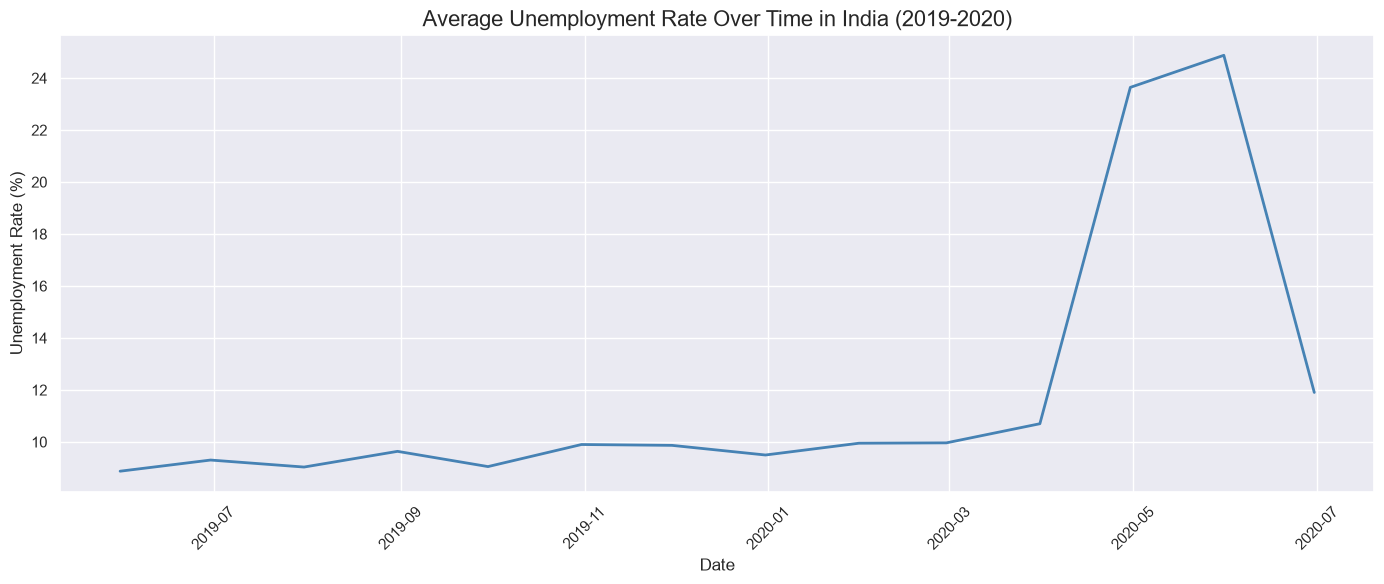

In [5]:
trend = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend, x='Date', y='Estimated Unemployment Rate (%)', color='steelblue', linewidth=2)
plt.title("Average Unemployment Rate Over Time in India (2019-2020)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Region-wise Unemployment

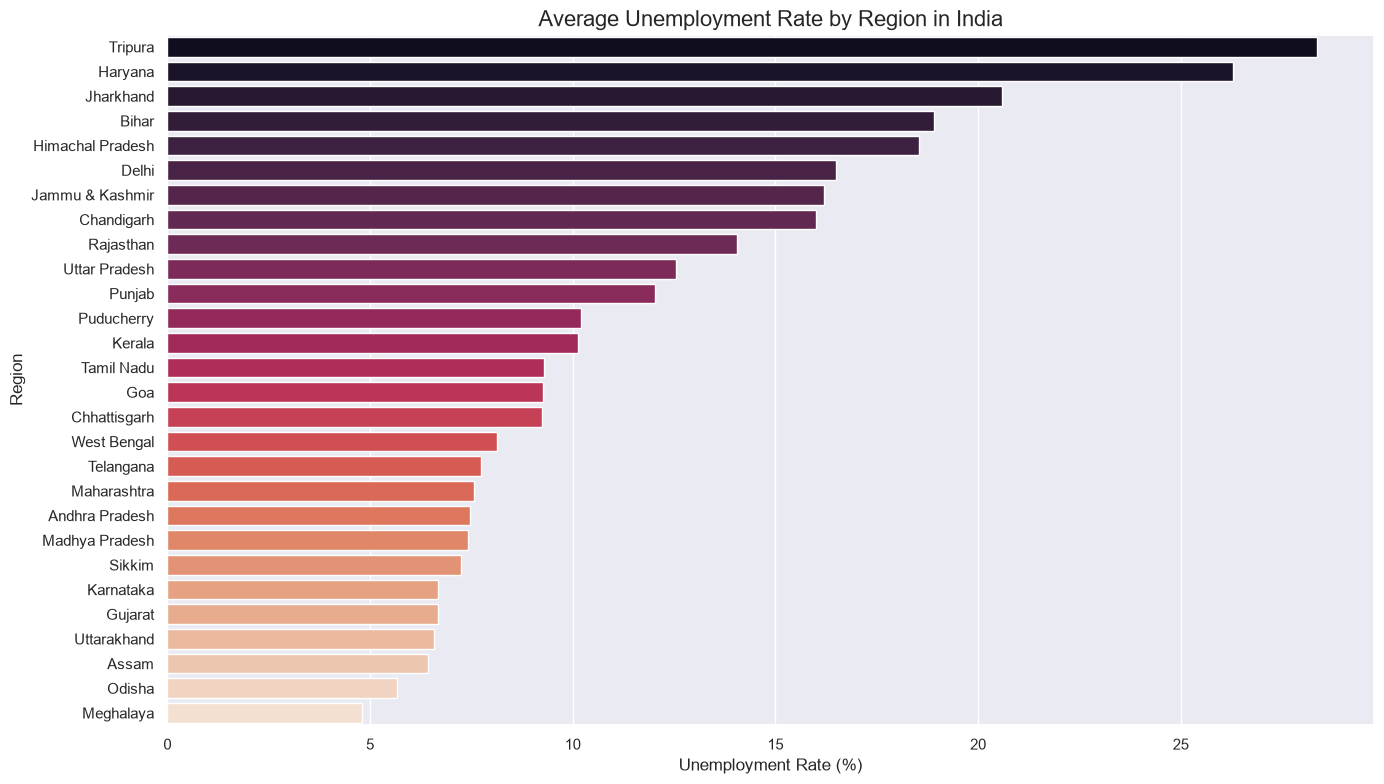

In [6]:
region_avg = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(data=region_avg, x='Estimated Unemployment Rate (%)', y='Region', hue='Region', palette='rocket', legend=False)
plt.title("Average Unemployment Rate by Region in India", fontsize=16)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 5. Urban vs Rural Unemployment

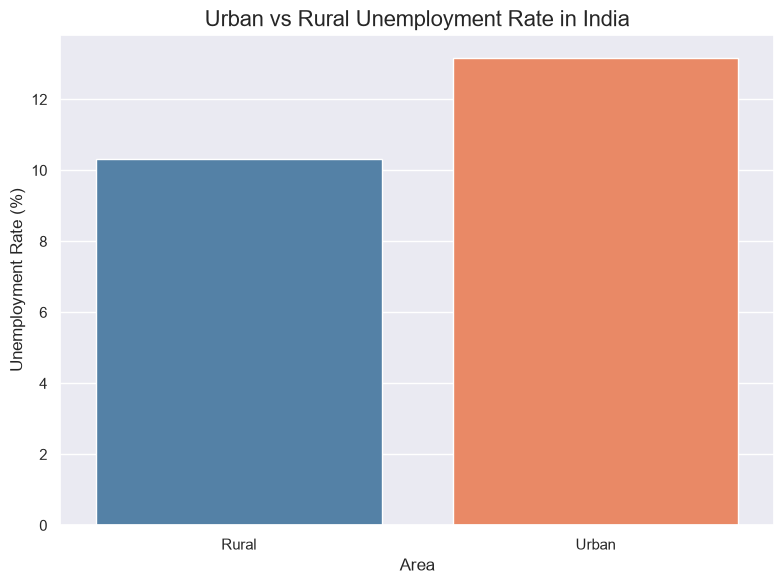

In [7]:
area_avg = df1.groupby('Area')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=area_avg, x='Area', y='Estimated Unemployment Rate (%)', hue='Area', palette=['steelblue', 'coral'], legend=False)
plt.title("Urban vs Rural Unemployment Rate in India", fontsize=16)
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

## 6. Covid-19 Impact Analysis

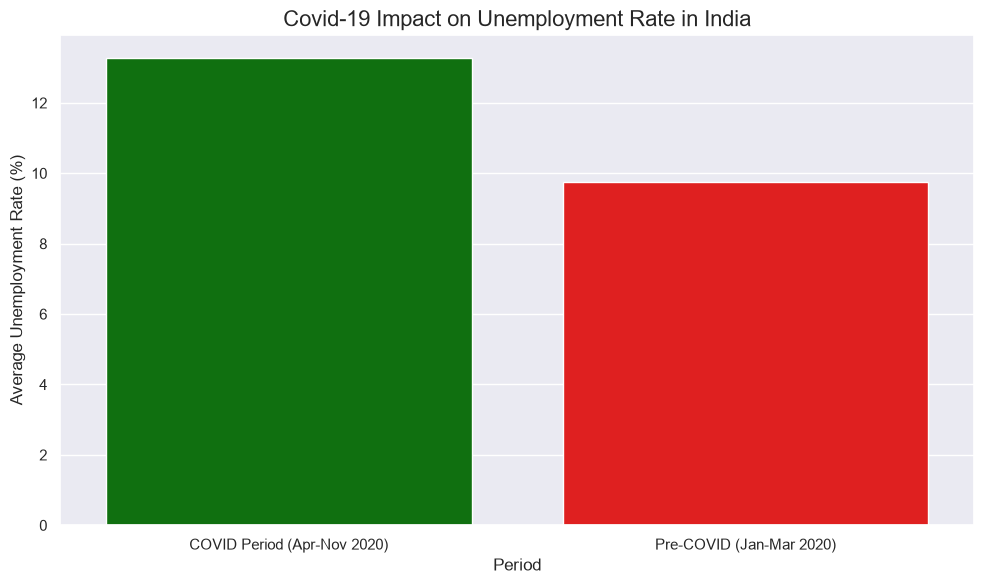

In [8]:
df2['Period'] = df2['Date'].apply(lambda x: 'Pre-COVID (Jan-Mar 2020)' if x.month <= 3 else 'COVID Period (Apr-Nov 2020)')

covid_impact = df2.groupby('Period')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=covid_impact, x='Period', y='Estimated Unemployment Rate (%)', hue='Period', palette=['green', 'red'], legend=False)
plt.title("Covid-19 Impact on Unemployment Rate in India", fontsize=16)
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

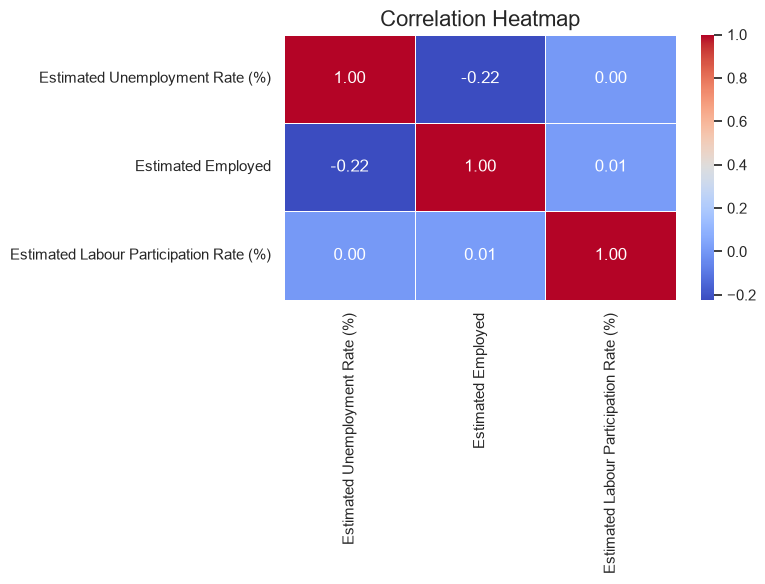

In [9]:
numeric_cols = df1[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## 8. Key Insights & Conclusions

- **Unemployment spiked significantly in 2020** compared to 2019, directly linked to Covid-19 lockdowns
- **Urban areas** have higher unemployment rates than Rural areas — urban workers were more affected by lockdowns
- **Tripura and Haryana** have the highest average unemployment rates among Indian states
- **Covid-19 impact** is clearly visible — unemployment jumped from ~8% pre-COVID to ~20%+ during COVID period
- **Labour Participation Rate** shows a negative correlation with Unemployment Rate — when more people participate, unemployment drops
- The data suggests targeted economic policies are needed for high-unemployment states like Tripura and Haryana